**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppresses all warning messages

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

**Load Dataset**

In [267]:
df = pd.read_csv("../data/Churn_Modelling.csv")

print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

**Explore Dataset**

In [268]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore   

**Drop Unnecessary Columns**

In [269]:
df = df.drop(
    ["RowNumber",
     "CustomerId",
     "Surname"],
    axis=1
)

**Encode Gender**

In [270]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(
    df["Gender"]
)

**One-Hot Encode Geography**

In [271]:
df = pd.get_dummies(
    df,
    columns=["Geography"],
    drop_first=True
)

**Separate Features and Labels**

In [272]:
X = df.drop(
    "Exited",
    axis=1
)

y = df["Exited"]

**Train-Test Split**

In [273]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Feature Scaling**

In [274]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Build Neural Network**

In [275]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(X_train.shape[1],)), 

    tf.keras.layers.Dense(
        64,
        activation='relu',
    ),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Compile**

In [276]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train**

In [277]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7872 - loss: 0.4951 - val_accuracy: 0.8175 - val_loss: 0.4263
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8078 - loss: 0.4456 - val_accuracy: 0.8250 - val_loss: 0.4101
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8155 - loss: 0.4304 - val_accuracy: 0.8425 - val_loss: 0.3942
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8230 - loss: 0.4194 - val_accuracy: 0.8456 - val_loss: 0.3838
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8305 - loss: 0.3988 - val_accuracy: 0.8544 - val_loss: 0.3664
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8367 - loss: 0.3883 - val_accuracy: 0.8581 - val_loss: 0.3596
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8428 - loss: 0.3784 - val_accuracy: 0.8556 - val_loss: 0.3530
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8438 - loss: 0.3725 - val_accuracy: 0.

**Evaluate**

In [278]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8570 - loss: 0.3416
Accuracy: 0.8569999933242798


**Predictions**

In [279]:
pred = model.predict(X_test)

pred = (
    pred > 0.35
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


**Classification Report**

In [280]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1607
           1       0.64      0.59      0.62       393

    accuracy                           0.86      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.86      0.85      2000



**Confusion Matrix**

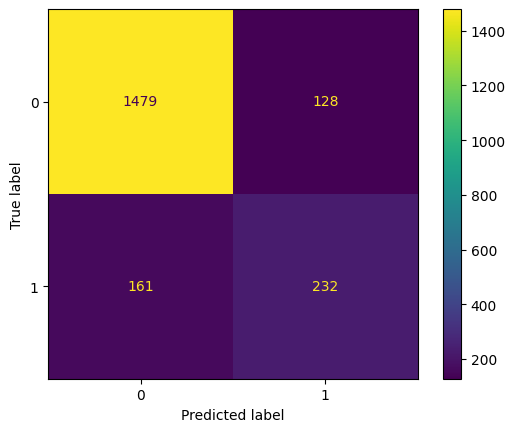

In [281]:
cm = confusion_matrix(
    y_test,
    pred
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**Save Model**

In [282]:
model.save("../models/heart_model.keras")

**Plot Training Curves**

Accuracy

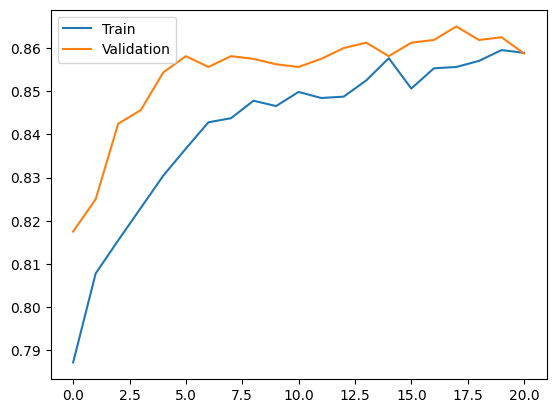

In [283]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.legend([
    'Train',
    'Validation'
])

plt.show()

Loss

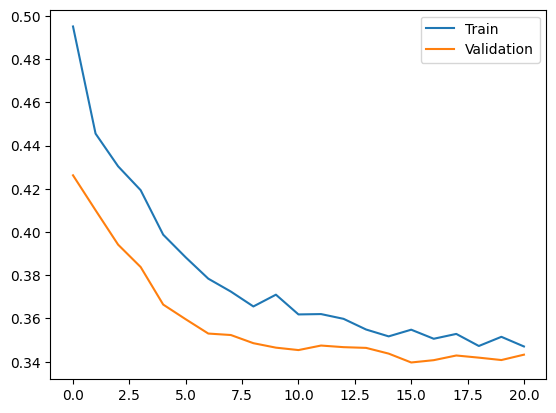

In [284]:
plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.legend([
    'Train',
    'Validation'
])

plt.show()